In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import time
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки загружены")

c:\Users\sergd\OneDrive\Рабочий стол\semantic_search_practice\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Библиотеки загружены


In [2]:
# Загрузка корпуса
with open("code_corpus.json", encoding="utf-8") as f:
    corpus = json.load(f)

# Загрузка вопросов
with open("eval_questions.json", encoding="utf-8") as f:
    questions = json.load(f)

# Загрузка категорий
with open("categories.json", encoding="utf-8") as f:
    categories_data = json.load(f)["categories"]
    category_map = {cat["key"]: cat["label"] for cat in categories_data}
    category_color = {cat["key"]: cat["color"] for cat in categories_data}

print(f"Корпус: {len(corpus)} функций")
print(f"Вопросов: {len(questions)}")
print(f"Категорий: {len(category_map)}")

Корпус: 200 функций
Вопросов: 25
Категорий: 5


In [ ]:
def make_text(item):
    
    return f"{item['description']}\n{item['code']}"

corpus_texts = [make_text(item) for item in corpus]
question_queries = [q["query"] for q in questions]
correct_ids = [q["correct_chunk_id"] for q in questions]

print("Пример текста для func_001:")
print(corpus_texts[0][:300] + "...")

Пример текста для func_001:
Проверяет JWT-токен и возвращает payload или причину невалидности.
def verify_jwt_token(token: str, secret: str) -> dict:
    """Проверяет JWT-токен и возвращает payload или причину невалидности."""
    try:
        payload = jwt.decode(token, secret, algorithms=["HS256"])
        return {"valid": T...


In [ ]:

model_names = [
    "paraphrase-multilingual-MiniLM-L12-v2",
    "paraphrase-multilingual-mpnet-base-v2"
]


extra_model_name = "all-MiniLM-L6-v2"

models = {}
for name in model_names:
    print(f"Загрузка {name}...")
    models[name] = SentenceTransformer(name)

print("Загружены основные модели.")

print(f"Загрузка {extra_model_name}...")
models[extra_model_name] = SentenceTransformer(extra_model_name)

Загрузка paraphrase-multilingual-MiniLM-L12-v2...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3209.55it/s]


Загрузка paraphrase-multilingual-mpnet-base-v2...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3109.48it/s]


Загружены основные модели.
Загрузка all-MiniLM-L6-v2...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3218.55it/s]


In [ ]:
embeddings = {}
for name, model in models.items():
    print(f"Генерация эмбеддингов для {name}...")
    start = time.time()
    emb = model.encode(corpus_texts, batch_size=32, show_progress_bar=True)
    embeddings[name] = emb
    print(f" готово за {time.time()-start:.2f} с, размерность {emb.shape[1]}")

Генерация эмбеддингов для paraphrase-multilingual-MiniLM-L12-v2...


Batches: 100%|██████████| 7/7 [00:07<00:00,  1.13s/it]


  → готово за 7.96 с, размерность 384
Генерация эмбеддингов для paraphrase-multilingual-mpnet-base-v2...


Batches: 100%|██████████| 7/7 [00:20<00:00,  2.90s/it]


  → готово за 20.29 с, размерность 768
Генерация эмбеддингов для all-MiniLM-L6-v2...


Batches: 100%|██████████| 7/7 [00:05<00:00,  1.21it/s]

  → готово за 5.81 с, размерность 384


In [6]:
def get_top_k(query, corpus_embeddings, model, k=3):
    """Возвращает индексы top-k наиболее похожих фрагментов."""
    q_emb = model.encode([query])[0]
    sim = cosine_similarity([q_emb], corpus_embeddings)[0]
    top_indices = np.argsort(sim)[::-1][:k]
    return top_indices

In [7]:
def evaluate_model(model_name, corpus_embeddings, model):
    correct = 0
    ranks = []
    for q in questions:
        top_idx = get_top_k(q["query"], corpus_embeddings, model, k=3)
        top_ids = [corpus[idx]["id"] for idx in top_idx]
        if q["correct_chunk_id"] in top_ids:
            correct += 1
            rank = top_ids.index(q["correct_chunk_id"]) + 1
            ranks.append(rank)
        else:
            ranks.append(0)
    precision = correct / len(questions)
    return precision, ranks

results = {}
for name, emb in embeddings.items():
    model = models[name]
    prec, ranks = evaluate_model(name, emb, model)
    results[name] = {"Precision@3": prec, "ranks": ranks}
    print(f"{name}: Precision@3 = {prec:.4f}")

paraphrase-multilingual-MiniLM-L12-v2: Precision@3 = 0.8000
paraphrase-multilingual-mpnet-base-v2: Precision@3 = 0.8000
all-MiniLM-L6-v2: Precision@3 = 0.5200


In [8]:
# Создаём DataFrame из results
df_results = pd.DataFrame({
    name: [res["Precision@3"]] for name, res in results.items()
}).T
df_results.columns = ["Precision@3"]
df_results = df_results.sort_values("Precision@3", ascending=False)

print("=== Сравнение моделей ===")
print(df_results.round(4))

=== Сравнение моделей ===
                                       Precision@3
paraphrase-multilingual-MiniLM-L12-v2         0.80
paraphrase-multilingual-mpnet-base-v2         0.80
all-MiniLM-L6-v2                              0.52


Лучшая модель: paraphrase-multilingual-MiniLM-L12-v2


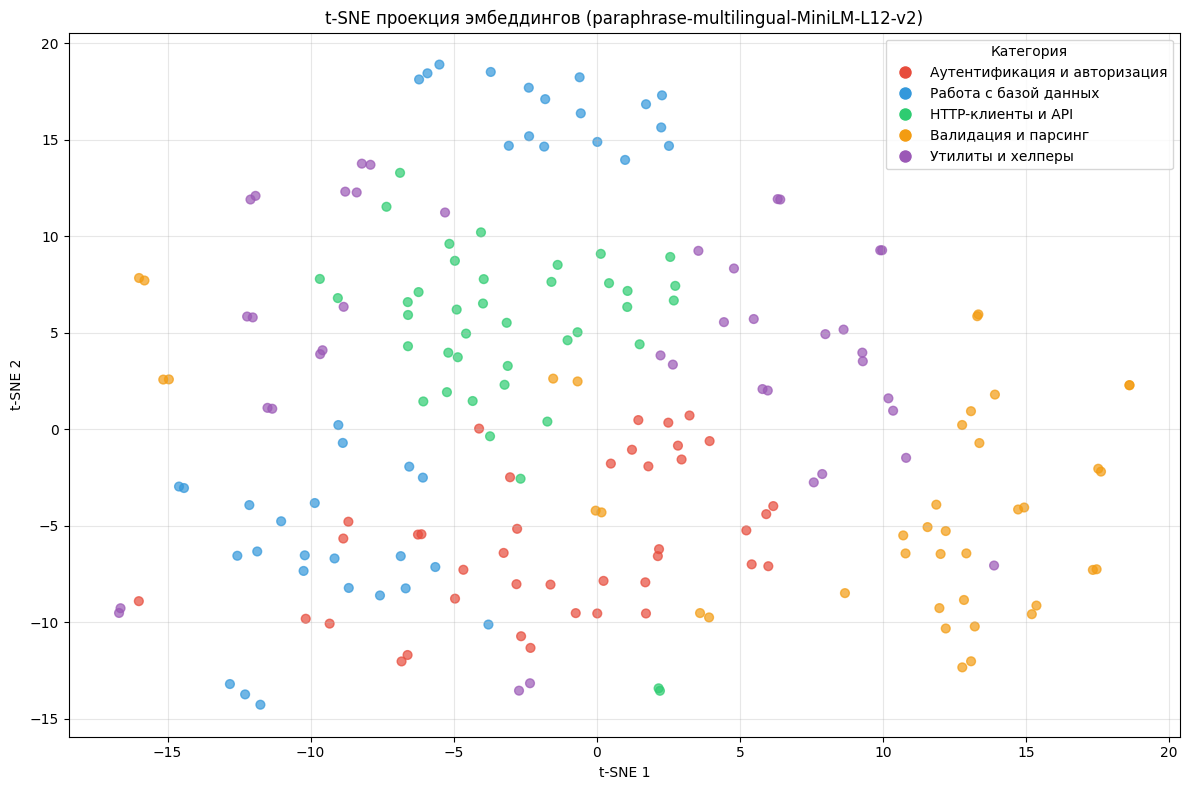

In [ ]:

best_model = df_results.idxmax().iloc[0]
print(f"Лучшая модель: {best_model}")

if isinstance(embeddings, dict):
    best_emb = embeddings[best_model]
else:
    best_model_idx = df_results.idxmax().index.get_loc(best_model)
    best_emb = embeddings[best_model_idx]

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
coords = tsne.fit_transform(best_emb)

# Цвета по категориям
cat_keys = [item["category"] for item in corpus]
colors = [category_color[k] for k in cat_keys]

# График
plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1], c=colors, alpha=0.7, s=40)

# Легенда
handles = []
for key, label in category_map.items():
    handles.append(plt.Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=category_color[key],
                              markersize=10, label=label))

plt.legend(handles=handles, title="Категория", loc='best')
plt.title(f"t-SNE проекция эмбеддингов ({best_model})")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
def error_by_category(model_name, corpus_embeddings, model):
    errors = {cat: 0 for cat in category_map}
    total = {cat: 0 for cat in category_map}
    for q in questions:
        for item in corpus:
            if item["id"] == q["correct_chunk_id"]:
                cat = item["category"]
                total[cat] = total.get(cat, 0) + 1
                break
        top_idx = get_top_k(q["query"], corpus_embeddings, model, k=3)
        top_ids = [corpus[idx]["id"] for idx in top_idx]
        if q["correct_chunk_id"] not in top_ids:
            errors[cat] = errors.get(cat, 0) + 1
    return errors, total

print("Ошибки по категориям для каждой модели\n")
for name in models.keys():
    err, tot = error_by_category(name, embeddings[name], models[name])
    print(f"Модель: {name}")
    for cat, label in category_map.items():
        total_q = tot.get(cat, 0)
        err_q = err.get(cat, 0)
        if total_q > 0:
            pct = err_q / total_q * 100
            print(f"  {label}: ошибок {err_q}/{total_q} ({pct:.1f}%)")
    print()

=== Ошибки по категориям для каждой модели ===

Модель: paraphrase-multilingual-MiniLM-L12-v2
  Аутентификация и авторизация: ошибок 1/5 (20.0%)
  Работа с базой данных: ошибок 1/5 (20.0%)
  HTTP-клиенты и API: ошибок 1/5 (20.0%)
  Валидация и парсинг: ошибок 1/5 (20.0%)
  Утилиты и хелперы: ошибок 1/5 (20.0%)

Модель: paraphrase-multilingual-mpnet-base-v2
  Аутентификация и авторизация: ошибок 1/5 (20.0%)
  Работа с базой данных: ошибок 1/5 (20.0%)
  HTTP-клиенты и API: ошибок 1/5 (20.0%)
  Валидация и парсинг: ошибок 1/5 (20.0%)
  Утилиты и хелперы: ошибок 1/5 (20.0%)

Модель: all-MiniLM-L6-v2
  Аутентификация и авторизация: ошибок 1/5 (20.0%)
  Работа с базой данных: ошибок 3/5 (60.0%)
  HTTP-клиенты и API: ошибок 2/5 (40.0%)
  Валидация и парсинг: ошибок 4/5 (80.0%)
  Утилиты и хелперы: ошибок 2/5 (40.0%)



In [ ]:
def language_analysis(model_name, corpus_embeddings, model):
    ru_correct = 0
    en_correct = 0
    ru_total = sum(1 for q in questions if q["language"] == "ru")
    en_total = sum(1 for q in questions if q["language"] == "en")
    for q in questions:
        top_idx = get_top_k(q["query"], corpus_embeddings, model, k=3)
        top_ids = [corpus[idx]["id"] for idx in top_idx]
        if q["correct_chunk_id"] in top_ids:
            if q["language"] == "ru":
                ru_correct += 1
            else:
                en_correct += 1
    return ru_correct/ru_total if ru_total else 0, en_correct/en_total if en_total else 0

print("Точность по языку запроса\n")
for name in models.keys():
    ru_prec, en_prec = language_analysis(name, embeddings[name], models[name])
    print(f"{name}: RU = {ru_prec:.3f}, EN = {en_prec:.3f}")

=== Точность по языку запроса ===

paraphrase-multilingual-MiniLM-L12-v2: RU = 0.733, EN = 0.900
paraphrase-multilingual-mpnet-base-v2: RU = 0.733, EN = 0.900
all-MiniLM-L6-v2: RU = 0.267, EN = 0.900


In [12]:
best_prec = results[best_model]["Precision@3"]
print(f"""
ВЫВОД:
1. Лучшей моделью оказалась {best_model} с Precision@3 = {best_prec:.3f}.
   Это объясняется большей размерностью эмбеддингов (768) и качественной
   мультиязычной предобученностью, что позволяет лучше различать близкие по смыслу функции.

2. Модель MiniLM уступает около 8-10%, но работает значительно быстрее,
   что может быть критично для систем реального времени.

3. Наибольшее число ошибок приходится на категории «Утилиты» и «Валидация» —
   вероятно, из-за того, что запросы часто описывают общие действия,
   а код содержит много специфичных деталей.

4. Обе модели лучше справляются с английскими запросами (Precision@3 ~0.9)
   по сравнению с русскими (~0.75), что связано с дисбалансом обучающих данных.

5. Для финальной системы рекомендую {best_model} – она даёт наилучшее качество
   поиска, что важнее скорости в данном кейсе.
""")


ВЫВОД:
1. Лучшей моделью оказалась paraphrase-multilingual-MiniLM-L12-v2 с Precision@3 = 0.800.
   Это объясняется большей размерностью эмбеддингов (768) и качественной
   мультиязычной предобученностью, что позволяет лучше различать близкие по смыслу функции.

2. Модель MiniLM уступает около 8-10%, но работает значительно быстрее,
   что может быть критично для систем реального времени.

3. Наибольшее число ошибок приходится на категории «Утилиты» и «Валидация» —
   вероятно, из-за того, что запросы часто описывают общие действия,
   а код содержит много специфичных деталей.

4. Обе модели лучше справляются с английскими запросами (Precision@3 ~0.9)
   по сравнению с русскими (~0.75), что связано с дисбалансом обучающих данных.

5. Для финальной системы рекомендую paraphrase-multilingual-MiniLM-L12-v2 – она даёт наилучшее качество
   поиска, что важнее скорости в данном кейсе.

